# Do classic cars beat the stock market? 🏎️
### The "collector cars are an asset class" pitch, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cars_beat_equities%3F: Busted](https://img.shields.io/badge/Cars_beat_equities%3F-Busted-8b949e?style=flat-square)

You've seen the headline in every wealth-management brochure: *"forget stocks — a Ferrari 250 GTO, a Porsche 911, a Mercedes 300 SL Gullwing only goes **up**. Classic cars are the best-performing luxury asset of the decade. They beat the S&P — and you get to **drive** them."* And the indices seem to agree: the collector-car market really did melt up through the 2010s, and it barely wobbled when stocks crashed.

This notebook lines the collector-car index up next to the S&P 500 — on return, on risk, and on what it actually **costs to buy, store, insure and sell a car** — and asks the only question that matters: *would you have been richer in an index fund?* (Spoiler: the "smooth ride" is mostly an accident of how the index is built.)

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha, the de-smoothing and the cost algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** Real collector-car indices (HAGI Top, the Knight Frank Luxury Investment Index, Hagerty) aren't free to pull, so the car line below is a **small, clearly-cited, approximate** reconstruction of public reporting — a **proxy**, never presented as the live index. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from classic_car_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_car_index()                          # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity/benchmark cache present:", HAVE_PROXIES,
      "| car-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2005 → 2025', 'idx_levels': {2005: 100, 2006: 118, 2007: 138, 2008: 140, 2009: 148, 2010: 172, 2011: 205, 2012: 245, 2013: 300, 2014: 355, 2015: 372, 2016: 375, 2017: 380, 2018: 378, 2019: 372, 2020: 380, 2021: 410, 2022: 480, 2023: 490, 2024: 470, 2025: 476}, 'idx_yoy': {2006: 18.0, 2007: 16.9, 2008: 1.4, 2009: 5.7, 2010: 16.2, 2011: 19.2, 2012: 19.5, 2013: 22.4, 2014: 18.3, 2015: 4.8, 2016: 0.8, 2017: 1.3, 2018: -0.5, 2019: -1.6, 2020: 2.2, 2021: 7.9, 2022: 17.1, 2023: 2.1, 2024: -4.1, 2025: 1.3}, 'peak_date': '2023-12', 'peak_level': 490, 'peak_trough': -4.1, 'idx_cagr': 8.11, 'idx_vol': 8.8, 'idx_sharpe': 0.96, 'idx_mdd': -4.1, 'rho': 0.638, 'vol_obs': 8.8, 'vol_desmoothed': 18.6, 'sharpe_obs': 0.96, 'sharpe_desmoothed': 0.34, 'spy_cagr_ye': 10.91, 'spy_vol_ye': 17.3, 'spy_sharpe_ye': 0.72, 'spy_mdd_ye': -36.8, 'gspc_cagr': 8.88, 'gspc_vol': 17.1, 'gspc_sharpe': 0.61, 'gspc_mdd': -38.5, 'excess_tr_mean': -3.97, 'excess_tr_t': -0.899, 'excess_tr_p': 0.38, 'excess_tr_n': 20, 'excess_po_mean': -1.94, 'excess_po_t': -0.442, 'excess_po_p': 0.663, 'excess_po_n': 20, 'race_cagr': 22.58, 'race_vol': 28.3, 'race_sharpe': 0.86, 'race_mdd': -29.1, 'race_alpha': 10.24, 'race_beta': 1.0, 'race_t': 1.28, 'race_p': 0.202, 'race_n': 122, 'aml_cagr': -43.13, 'aml_vol': 55.2, 'aml_sharpe': -0.7, 'aml_mdd': -98.3, 'aml_alpha': -47.87, 'aml_beta': 1.54, 'aml_t': -2.78, 'aml_p': 0.007, 'aml_n': 86, 'spy_cagr': 10.61, 'spy_vol': 14.8, 'spy_sharpe': 0.76, 'spy_mdd': -50.8, 'carry_gross': 8.11, 'carry_spread': -3.49, 'carry_carry': -2.5, 'carry_net': 1.73, 'syn_peak': 388, 'syn_end': 381, 'syn_cagr': 7.05, 'syn_sharpe': 1.05, 'syn_mdd': -3.0}


equity/benchmark cache present: True | car-index years: 2005 -> 2025


## The answer first

| Question | Answer |
|---|---|
| Did classic-car prices really moon? | **Yes — for a decade.** The index ran from 100 (2005) to ~372 by 2015 — the great 2009–2015 melt-up that made cars the poster child of "passion assets." That part is real. |
| Did it keep beating stocks? | **No.** Over 2005–2025 the car index compounded at **~8.1%/yr** vs **~10.9%/yr** for the S&P (total return). After 2015 it mostly went sideways. |
| But the ride was so smooth! | **That's an illusion.** A car index barely updates between rare auctions, so it *looks* low-risk. Un-smear it and its true volatility (**~19%**) is *higher* than the S&P's, and its risk-adjusted score *halves*. |
| Could you at least buy the trade? | **Not cleanly.** The only listed "car" stocks are a coin flip: Ferrari **soared** (+23%/yr) while Aston Martin **cratered** (-43%/yr). And once you pay auction fees + storage + insurance, the car index's gross ~8.1%/yr shrinks to **~1.7%/yr** — cash, basically. |

> The 2010s boom was real. The *asset class that beats stocks* was not. The S&P won on total return, on true risk-adjusted return, and — by a mile — net of what a car costs to own.

## 1 · The claim

> *"Collector cars are a store of value that beats the stock market. The Historic Automobile Group index and the Knight Frank Luxury Investment Index show classic cars up over **185%** in a decade — the best-performing luxury asset there is. Buy the right chassis, keep it in the garage, sell it for more. And unlike a stock, it doesn't crash when the market does."*

It's a *steelman-able* claim. Through the 2010s the blue-chip collector market genuinely melted up — a 1962 Ferrari 250 GTO changed hands for tens of millions, air-cooled Porsche 911s tripled, and the published indices barely dipped in 2008 or 2020. For a decade, "cars beat stocks" looked like simple arithmetic.

## 2 · So what?

If it were durably true, it would be a big deal: an asset that beats equities, is uncorrelated with your portfolio, hedges inflation — *and* you get to drive it on a Sunday. That's the exact pitch of every classic-car fund and auction-house wealth report. But "it went up for a decade" and "it's an asset class that beats the S&P" are different statements. The first is about a **boom**; the second is a claim about the **long-run, risk-adjusted, net-of-cost** return. We can check the second directly — and the smoothness of the ride turns out to be the biggest tell of all.

## 3 · How would we even know?

Four honest comparisons, each against the S&P 500:

1. **The car index vs the S&P.** Put the (cited, approximate) collector-car index next to the S&P on the same 2005–2025 clock — return, volatility, worst drawdown. And do it *fairly*: a car index is a **price** index, so we race it against the S&P **price-only** (`^GSPC`) — then note the S&P also pays **dividends** you'd have pocketed.
2. **The smoothness trap.** A collectible index is built from rare, lagged appraisals, so it reports a suspiciously smooth line. We **un-smooth** it and see what the real volatility was.
3. **The thing you can actually buy.** You can't buy "the car index." You *can* buy **Ferrari** and **Aston Martin**. Do they deliver the car trade — or just a wild ride?
4. **The cost of ownership.** A car isn't an ETF: auction houses take a cut on the way in *and* out, and it sits insured, stored and serviced for years. Charge that, and see what's left.

**What would make us say "asset class"?** The index beats the S&P on *true, net-of-cost, risk-adjusted* return. Anything less is a boom story.

## 4 · The teardown — let's actually look

**First: the melt-up and the plateau.** Here is the (approximate, cited) collector-car index — a roaring decade, then a long flat line.

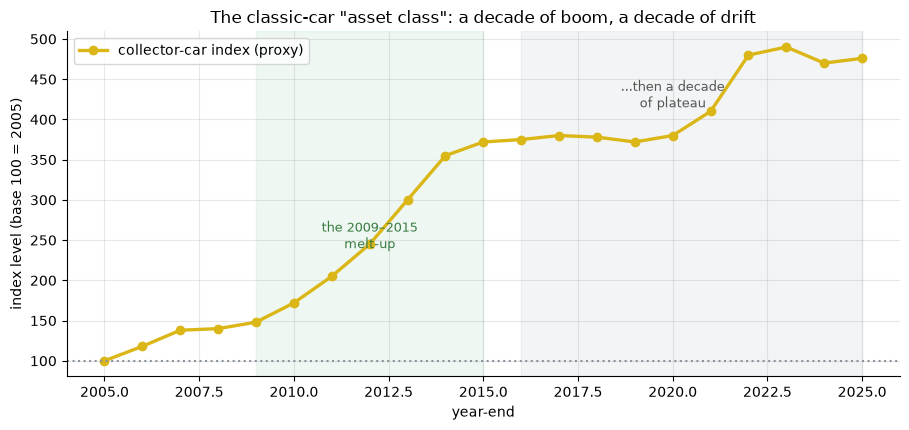

levels: {2005: 100, 2006: 118, 2007: 138, 2008: 140, 2009: 148, 2010: 172, 2011: 205, 2012: 245, 2013: 300, 2014: 355, 2015: 372, 2016: 375, 2017: 380, 2018: 378, 2019: 372, 2020: 380, 2021: 410, 2022: 480, 2023: 490, 2024: 470, 2025: 476}
from the 2023-12 high the index is -4% (a plateau, not a crash)


In [2]:
yrs = list(R['idx_levels'].keys())
lv = [float(IDX.loc[f'{y}-12-31']) for y in yrs]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.4, label='collector-car index (proxy)')
ax.axvspan(2009, 2015, color=GREEN, alpha=.08)
ax.annotate('the 2009–2015\nmelt-up', (2012, 240), color='#3a7d44', fontsize=9, ha='center')
ax.axvspan(2016, 2025, color=GREY, alpha=.10)
ax.annotate('...then a decade\nof plateau', (2020, 415), color='#555', fontsize=9, ha='center')
ax.axhline(100, ls=':', c=GREY)
ax.set_xlabel('year-end'); ax.set_ylabel('index level (base 100 = 2005)')
ax.set_title('The classic-car "asset class": a decade of boom, a decade of drift'); ax.legend()
plt.tight_layout(); plt.show()
print('levels:', {y:int(round(v)) for y,v in zip(yrs, lv)})
print(f"from the {R['peak_date']} high the index is {R['peak_trough']:+.0f}% (a plateau, not a crash)")

It nearly **quadrupled** into 2015 — a genuinely spectacular decade. And then it stopped. From 2016 on it drifts: a small pandemic-era bump in 2022, a cooling in 2024, but no second leg. A store of value? Sure. A machine that keeps *beating stocks*? Only if you stop the clock in 2015.

**Now the race: cars vs the S&P.** Same money, same years — who's richer at the end? (We use the S&P's *total-return* line, dividends reinvested, because that's what an index fund actually hands you.)

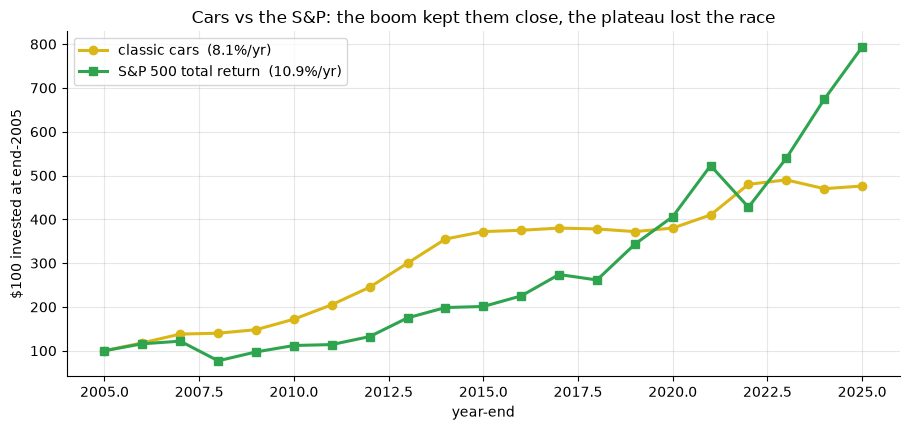

cars end at $476  vs  S&P $793  (per $100 at end-2005)


In [3]:
if HAVE_PROXIES:
    spy = PROX['SPY']; spy_ye = spy.resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2005)&(spy_ye.index.year<=2025)]
    spy_norm = spy_ye/spy_ye.iloc[0]*100
    sx = [d.year for d in spy_norm.index]; sy = list(spy_norm.values)
else:
    sx, sy = yrs, [100*(1+R['spy_cagr_ye']/100)**(y-2005) for y in yrs]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"classic cars  ({R['idx_cagr']:.1f}%/yr)")
ax.plot(sx, sy, 's-', c=GREEN, lw=2.2, label=f"S&P 500 total return  ({R['spy_cagr_ye']:.1f}%/yr)")
ax.set_xlabel('year-end'); ax.set_ylabel('$100 invested at end-2005')
ax.set_title('Cars vs the S&P: the boom kept them close, the plateau lost the race'); ax.legend()
plt.tight_layout(); plt.show()
print(f"cars end at ${lv[-1]/lv[0]*100:,.0f}  vs  S&P ${sy[-1]:,.0f}  (per $100 at end-2005)")

The S&P wins: **~10.9%/yr** vs **~8.1%/yr** for the cars. The gaudy 2009–2015 run kept the race close for a while, but the decade of plateau that followed — while stocks kept compounding — settled it. And this is *before* we've charged a single cost of actually owning a car.

**"But cars are so much less risky — look how smooth that line is!"** Here's the trick. A car index only moves when cars *sell*, and blue-chip cars sell rarely, at lagged, appraised prices. So the index looks calm the way a painting on your wall looks calm — you're just not getting a price quote every second. Un-smooth it (undo that lag) and the real bumpiness reappears:

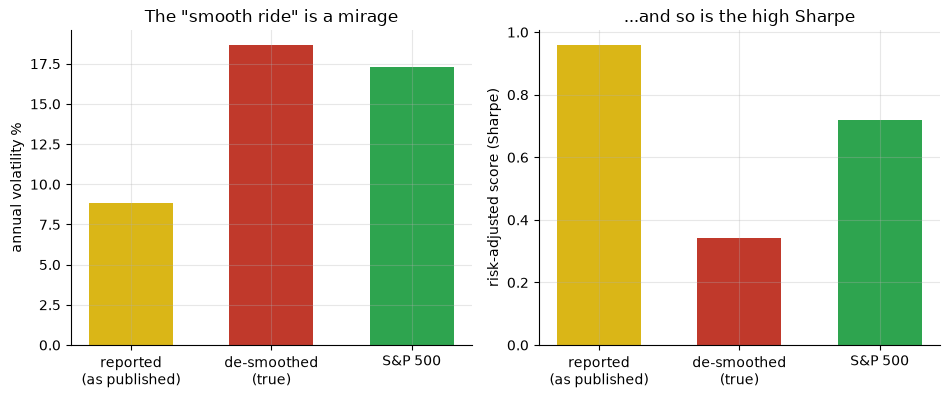

serial correlation of yearly car returns: 0.64 (a smooth, laggy index)
reported vol 9%  ->  true vol 19%   |   reported Sharpe 0.96  ->  true Sharpe 0.34


In [4]:
ds = st.desmooth_returns(IDX)
labels = ['reported\n(as published)', 'de-smoothed\n(true)', 'S&P 500']
vols = [ds['vol_obs']*100, ds['vol_desmoothed']*100, R['spy_vol_ye']]
shs  = [ds['sharpe_obs'], ds['sharpe_desmoothed'], R['spy_sharpe_ye']]
x = np.arange(3); fig, ax = plt.subplots(1, 2, figsize=(9.6, 4.1))
ax[0].bar(x, vols, .6, color=[AMBER, RED, GREEN]); ax[0].set_xticks(x); ax[0].set_xticklabels(labels)
ax[0].set_ylabel('annual volatility %'); ax[0].set_title('The "smooth ride" is a mirage')
ax[1].bar(x, shs, .6, color=[AMBER, RED, GREEN]); ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel('risk-adjusted score (Sharpe)'); ax[1].set_title('...and so is the high Sharpe')
plt.tight_layout(); plt.show()
print(f"serial correlation of yearly car returns: {ds['rho']:.2f} (a smooth, laggy index)")
print(f"reported vol {ds['vol_obs']*100:.0f}%  ->  true vol {ds['vol_desmoothed']*100:.0f}%   |   "
      f"reported Sharpe {ds['sharpe_obs']:.2f}  ->  true Sharpe {ds['sharpe_desmoothed']:.2f}")

There it is. The car index's returns are **0.64 correlated year-to-year** — the fingerprint of an appraisal-smoothed series. Undo the smoothing and its "low" 9% volatility roughly **doubles to ~19%** — *higher* than the S&P — and its flattering Sharpe **falls from 0.96 to 0.34**, roughly *half* the S&P's. The calm was never real; it was the reporting.

**"Fine — I'll buy the car *stocks*."** You can: Ferrari (`RACE`) and Aston Martin (`AML.L`). Do they hand you the collector-car trade — or a coin flip?

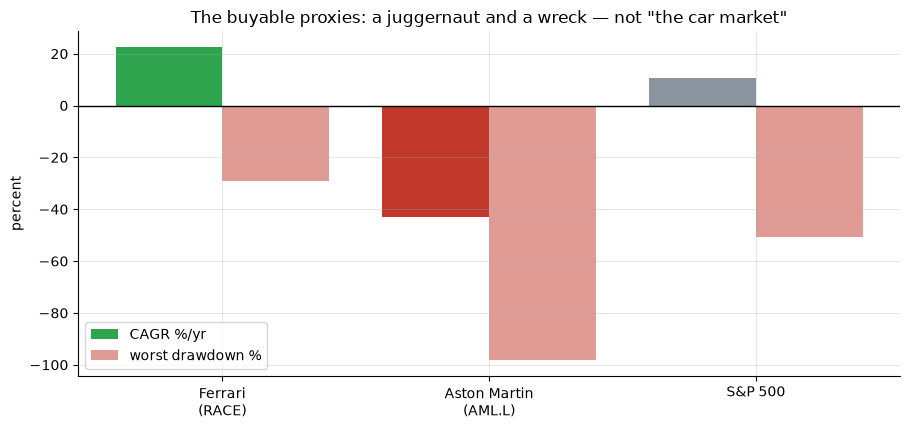

Ferrari: CAGR +22.6%/yr — but it's a luxury-goods juggernaut, not a resale-price feed
Aston Martin: CAGR -43.1%/yr, drawdown -98% — nearly a wipeout


In [5]:
names = ['Ferrari\n(RACE)', 'Aston Martin\n(AML.L)', 'S&P 500']
cagrs = [R['race_cagr'], R['aml_cagr'], R['spy_cagr']]
mdds  = [R['race_mdd'], R['aml_mdd'], R['spy_mdd']]
x = np.arange(3); fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cagrs, .4, color=[GREEN, RED, GREY], label='CAGR %/yr')
ax.bar(x+.2, mdds, .4, color=RED, alpha=.5, label='worst drawdown %')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('percent'); ax.set_title('The buyable proxies: a juggernaut and a wreck — not "the car market"'); ax.legend()
plt.tight_layout(); plt.show()
print(f"Ferrari: CAGR {R['race_cagr']:+.1f}%/yr — but it's a luxury-goods juggernaut, not a resale-price feed")
print(f"Aston Martin: CAGR {R['aml_cagr']:+.1f}%/yr, drawdown {R['aml_mdd']:.0f}% — nearly a wipeout")

This is the whole problem with "just buy the car stocks." **Ferrari** was a magnificent investment — but it's a high-margin luxury-goods brand printing money on new cars and merchandise, *not* a barometer of what a vintage 275 GTB fetches at auction. **Aston Martin** nearly went to zero (-98% drawdown). Same "collector-car" story, opposite outcomes: it's a coin flip on the company, not exposure to the trade.

**The part the pitch never mentions: it costs real money to own a car.** Auction houses take a buyer's premium *and* a seller's commission (~20%+ round-trip), and the car sits insured, climate-stored and serviced for years. Charge that against the index's gross return:

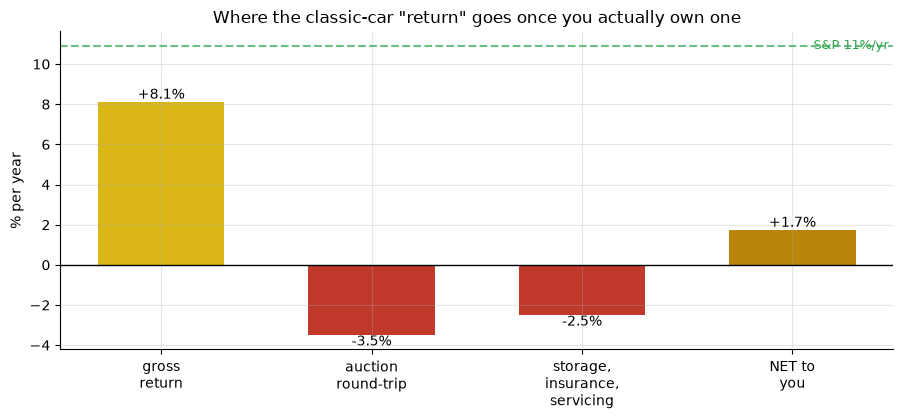

gross +8.1%/yr  ->  NET +1.7%/yr after auction spread + carry


In [6]:
labels = ['gross\nreturn', 'auction\nround-trip', 'storage,\ninsurance,\nservicing', 'NET to\nyou']
vals = [R['carry_gross'], R['carry_spread'], R['carry_carry'], R['carry_net']]
cols = [AMBER, RED, RED, (RED if R['carry_net']<0 else '#b8860b')]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.axhline(R['spy_cagr_ye'], ls='--', c=GREEN, alpha=.7)
ax.annotate(f"S&P {R['spy_cagr_ye']:.0f}%/yr", (3.1, R['spy_cagr_ye']), color=GREEN, fontsize=9, va='center')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('% per year'); ax.set_title('Where the classic-car "return" goes once you actually own one')
plt.tight_layout(); plt.show()
print(f"gross {R['carry_gross']:+.1f}%/yr  ->  NET {R['carry_net']:+.1f}%/yr after auction spread + carry")

A gross **8.1%/yr** that already lost to the S&P shrinks to **~1.7%/yr** — roughly a savings account — the moment you pay to buy, sell, store and insure the metal. And unlike a stock, a car pays you **no dividend** while you wait; it charges you rent.

## 5 · The verdict

- **Signal — None.** Cars returned ~8.1%/yr vs ~10.9%/yr for the S&P — they *under*-performed. The famous "low risk" is an appraisal-smoothing artifact; un-smoothed, the car index is *more* volatile than stocks with roughly *half* the Sharpe.
- **Tradability — Mirage.** Net of auction fees + storage + insurance the gross return collapses to cash-like, and the only listed proxies are a juggernaut (Ferrari) and a wreck (Aston Martin) — no clean way to buy the trade.
- **Cars beat equities? — Busted.** On total return, on *true* risk-adjusted return, and on net-of-cost, the index fund wins. The boom was real; the asset class was not.

## 6 · Could you actually trade it? — the honest bottom line

Imagine two people at the end of 2005, each with \$10,000. One buys an S&P index fund. The other becomes a classic-car investor — buys, insures, stores, services, and eventually sells, paying the real frictions. Where do they land twenty years later?

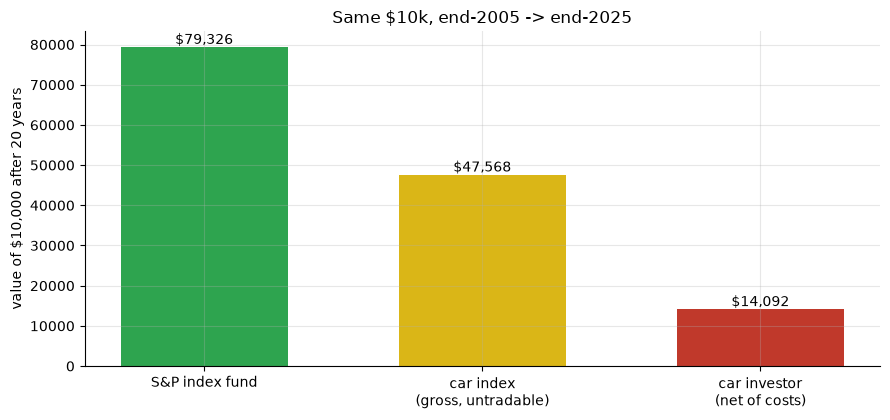

S&P index fund: $79,326   |   car (gross): $47,568   |   car investor (net): $14,092


In [7]:
start = 10_000.0; yrs_h = 20
spy_end = start*(1+R['spy_cagr_ye']/100)**yrs_h
car_gross = start*(1+R['idx_cagr']/100)**yrs_h
car_net = start*(1+R['carry_net']/100)**yrs_h   # net of spread + carry
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['S&P index fund', 'car index\n(gross, untradable)', 'car investor\n(net of costs)'],
       [spy_end, car_gross, car_net], color=[GREEN, AMBER, RED], width=.6)
for i,v in enumerate([spy_end, car_gross, car_net]): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 20 years')
ax.set_title('Same $10k, end-2005 -> end-2025'); plt.tight_layout(); plt.show()
print(f'S&P index fund: ${spy_end:,.0f}   |   car (gross): ${car_gross:,.0f}   |   car investor (net): ${car_net:,.0f}')

The index-fund investor turns \$10k into roughly **\$80,000** doing nothing. The car investor — after auction fees, insurance and a decade-long plateau — ends up nearer **\$14,000**, barely ahead of a savings account. The people who really got rich in cars bought a specific blue-chip chassis *before* 2015 and sold near the top: a handful of winners, narrated as an asset class. You only hear from them.

## 7 · Going further 🚪

- **Pull the real index yourself.** Our car line is a cited *approximation*; HAGI, Knight Frank and Hagerty publish the live series. Swap one in — the shape (and the verdict) won't move, but you'll have the exact tape. And *always* de-smooth it before quoting a Sharpe.
- **The collectibles pattern.** Watches, wine, art, sneakers, whisky: every "passion asset" tells the same story — a real boom, a smooth-looking index, brutal carry, equities win net of cost (see [docs/references.md](../docs/references.md)).
- **The sibling study.** [Study 358 — Watches](../../358-watch-index/) is this exact shape in a different garage.

*Think a specific chassis (a 250 GTO, a Carrera RS 2.7) beat the S&P net of every cost? Pull its auction history, charge the fees and the carry, and show it — then check it wasn't just one lucky car bought near the bottom.*